# 08 — Session Log Review & Human Tagging

Every mock-video eval writes a **full audit trail** under `outputs/har_sessions/`:

```
outputs/har_sessions/YYYY-MM-DD/<session_id>_<model_tag>/
  manifest.json      # model, video, classes
  events.jsonl       # one row per inference (track_id, frame, action, probs, bbox)
  summary.json       # counts by track / label
  frames/            # annotated full frames + person crops
  embeddings/        # .npy vectors (on label change / uncertain)
  index.csv          # cross-run index at har_sessions/
```

**Workflow**
1. Run **05_Mock_Video_Eval** (creates session logs + **person registry** via Re-ID)
2. Browse logs — per **track ID** timeline of model inferences
3. Tag tracks: *real person* vs false detection + optional **display name** → `person_registry`
4. **Person registry** — browse stable `global_person_id` history across sessions
5. Tag individual crops in **07_Human_Label_Review** (action correct/wrong)
6. Re-train with `include_human_labels=True` in pipeline **02 + 03**

In [1]:
import sys
from pathlib import Path
NB = Path.cwd()
if str(NB) not in sys.path:
    sys.path.insert(0, str(NB))

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image, Markdown

from lib.paths import SESSIONS_DIR, CHECKPOINTS_DIR, list_mock_videos
from lib.session_log import list_sessions
from lib.session_review import (
    session_dir_from_row,
    load_manifest,
    load_summary,
    events_dataframe,
    tracks_summary,
    plot_track_timeline,
    load_track_labels_df,
    launch_track_tagger,
    persons_dataframe,
    person_history_df,
    plot_person_history,
    launch_person_registry_viewer,
)
from lib.person_registry import REGISTRY_DB

## 1 — List recorded sessions

In [2]:
sessions = list_sessions(limit=50)
if not sessions:
    raise FileNotFoundError(
        'No sessions yet — run the render cell in 05_Mock_Video_Eval.ipynb first.'
    )

idx_df = pd.DataFrame(sessions)
display(idx_df[[
    'run_id', 'video', 'model_tag', 'n_events', 'n_confirmed', 'n_persons', 'session_dir'
]])

SESSION_ROW_INDEX = 0   # ← pick session to inspect
SESSION_DIR = session_dir_from_row(sessions[SESSION_ROW_INDEX])
print(f'\nSelected: {SESSION_DIR}')

,run_id,video,model_tag,n_events,n_confirmed,n_persons,session_dir
0,har-93944f1297de,Industrial-One.mp4,12c_topdown_allavail,23,7,6,2026-06-12/har-93944f1297de_12c_topdown_allavail
1,har-b4f1a20d0044,madera.mp4,12c_topdown_allavail,22,6,5,2026-06-12/har-b4f1a20d0044_12c_topdown_allavail
2,har-65e56a3bbd83,Industry-1.mp4,12c_topdown_allavail,23,7,6,2026-06-12/har-65e56a3bbd83_12c_topdown_allavail
3,har-edb582abee5d,Industry-1.mp4,12c_topdown_allavail,28,10,7,2026-06-12/har-edb582abee5d_12c_topdown_allavail
4,har-67a333a2aaa2,Madera-1.mp4,12c_topdown_allavail,22,6,5,2026-06-12/har-67a333a2aaa2_12c_topdown_allavail
5,har-d966e2cd9292,Madera-1.mp4,12c_topdown_allavail,22,6,5,2026-06-12/har-d966e2cd9292_12c_topdown_allavail
6,har-55da407f982a,Madera-1.mp4,12c_topdown_allavail,23,6,5,2026-06-12/har-55da407f982a_12c_topdown_allavail
7,har-d3bb05c01f71,Madera-1.mp4,12c_topdown_allavail,22,6,5,2026-06-12/har-d3bb05c01f71_12c_topdown_allavail
8,har-26703277b7c7,Madera-1.mp4,12c_topdown_allavail,22,6,5,2026-06-12/har-26703277b7c7_12c_topdown_allavail
9,har-d31422040454,Madera-1.mp4,12c_topdown_allavail,22,6,5,2026-06-12/har-d31422040454_12c_topdown_allavail



Selected: /Users/cpanoh/Documents/cpano-98-local/GitHub/AI-Co-Pilot-for-the-Production-Floor-See-Guide-Improve/har-research/outputs/har_sessions/2026-06-12/har-93944f1297de_12c_topdown_allavail


## 2 — Session manifest & per-track summary

Each **track_id** is one YOLO+ByteTrack person stream. The model runs HAR independently on each.

In [3]:
manifest = load_manifest(SESSION_DIR)
summary = load_summary(SESSION_DIR)
tracks = tracks_summary(SESSION_DIR)

display(Markdown(f"""
**Video:** {manifest.get('video')}  
**Session:** `{manifest.get('session_id')}`  
**Checkpoint:** {manifest.get('checkpoint_name')}  
**Events:** {summary.get('n_events', '?')} · **Tracks:** {summary.get('n_persons', '?')}
"""))

tracks_df = pd.DataFrame(tracks)
cols = [
    'track_id', 'global_person_id', 'n_inferences', 'frame_first', 'frame_last',
    'dominant_action', 'dominant_confidence', 'label_changes', 'uncertain_count',
]
display(tracks_df[[c for c in cols if c in tracks_df.columns]])


**Video:** Industrial-One.mp4  
**Session:** `har-93944f1297de`  
**Checkpoint:** har_vjepa_12c_topdown_allavail.pt  
**Events:** 23 · **Tracks:** 6


,track_id,global_person_id,n_inferences,frame_first,frame_last,dominant_action,dominant_confidence,label_changes,uncertain_count
0,1,,2,16,32,Turn sheets,0.6714,1,0
1,2,,6,16,96,Take measuring rod,0.9871,1,0
2,18,,5,32,96,Take measuring rod,0.6490,1,0
3,19,,4,48,96,Take measuring rod,0.9973,1,0
4,26,,3,48,96,Take measuring rod,0.9782,2,0
5,30,,3,64,96,Take measuring rod,0.9773,1,0


## 3 — Full inference log (every model call)

One row per inference: which **track**, at which **frame**, what **action** and **confidence**.

In [4]:
events_df = events_dataframe(SESSION_DIR)
cols = [
    'event_id', 'track_id', 'frame_idx', 'action_label', 'confidence',
    'raw_label', 'label_changed', 'uncertain', 'infer_ms', 'bbox'
]
display(events_df[cols].head(30))
print(f'… {len(events_df)} total inference events')

,event_id,track_id,frame_idx,action_label,confidence,raw_label,label_changed,uncertain,infer_ms,bbox
0,evt_00001,1,16,Turn sheets,0.5321,Turn sheets,True,False,10314.67,"[995, 316, 1059, 483]"
1,evt_00003,1,32,Turn sheets,0.6714,Turn sheets,False,False,2101.59,"[999, 318, 1060, 466]"
2,evt_00002,2,16,Take measuring rod,0.7949,Take measuring rod,True,False,1959.57,"[775, 502, 867, 784]"
3,evt_00004,2,32,Take measuring rod,0.9842,Take measuring rod,False,False,1569.07,"[784, 530, 864, 784]"
4,evt_00006,2,48,Take measuring rod,0.9871,Take measuring rod,False,False,1569.11,"[784, 527, 866, 780]"
5,evt_00010,2,64,Take measuring rod,0.9701,Take measuring rod,False,False,1601.29,"[783, 536, 866, 778]"
6,evt_00014,2,80,Take measuring rod,0.9614,Take measuring rod,False,False,1831.03,"[782, 535, 865, 784]"
7,evt_00019,2,96,Take measuring rod,0.9093,Take measuring rod,False,False,1691.01,"[782, 534, 866, 783]"
8,evt_00005,18,32,Take measuring rod,0.6490,Take measuring rod,True,False,1698.96,"[916, 206, 1002, 395]"
9,evt_00007,18,48,Take measuring rod,0.5572,Take measuring rod,False,False,1626.27,"[915, 201, 997, 394]"


… 23 total inference events


## 4 — Per-track timeline

See how the model's prediction evolves for one track ID over time.

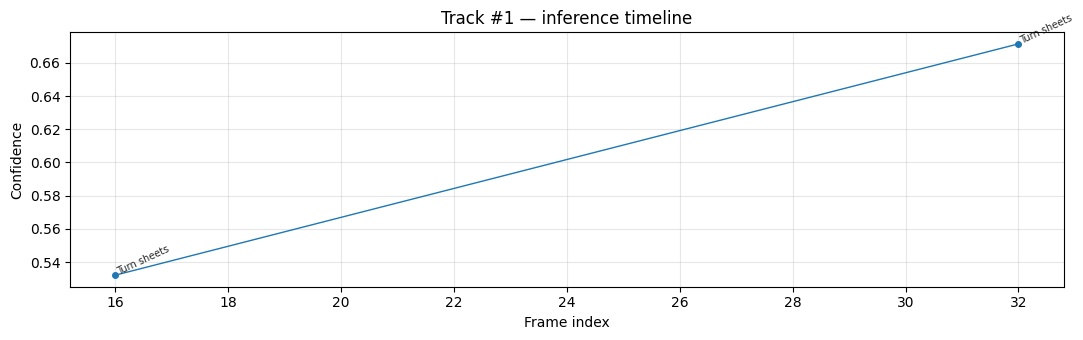

,frame_idx,action_label,confidence,label_changed,crop_path
0,16,Turn sheets,0.5321,True,2026-06-12/har-93944f1297de_12c_topdown_allava...
1,32,Turn sheets,0.6714,False,None


In [5]:
TRACK_ID = tracks[0]['track_id'] if tracks else 1   # ← change to inspect another track

fig, ax = plt.subplots(figsize=(11, 3.5))
plot_track_timeline(SESSION_DIR, TRACK_ID, ax=ax)
plt.tight_layout()
plt.show()

sub = events_df[events_df['track_id'] == TRACK_ID]
display(sub[['frame_idx', 'action_label', 'confidence', 'label_changed', 'crop_path']])

## 5 — Visual samples per track

Crop the model actually classified (YOLO person crop at inference time).

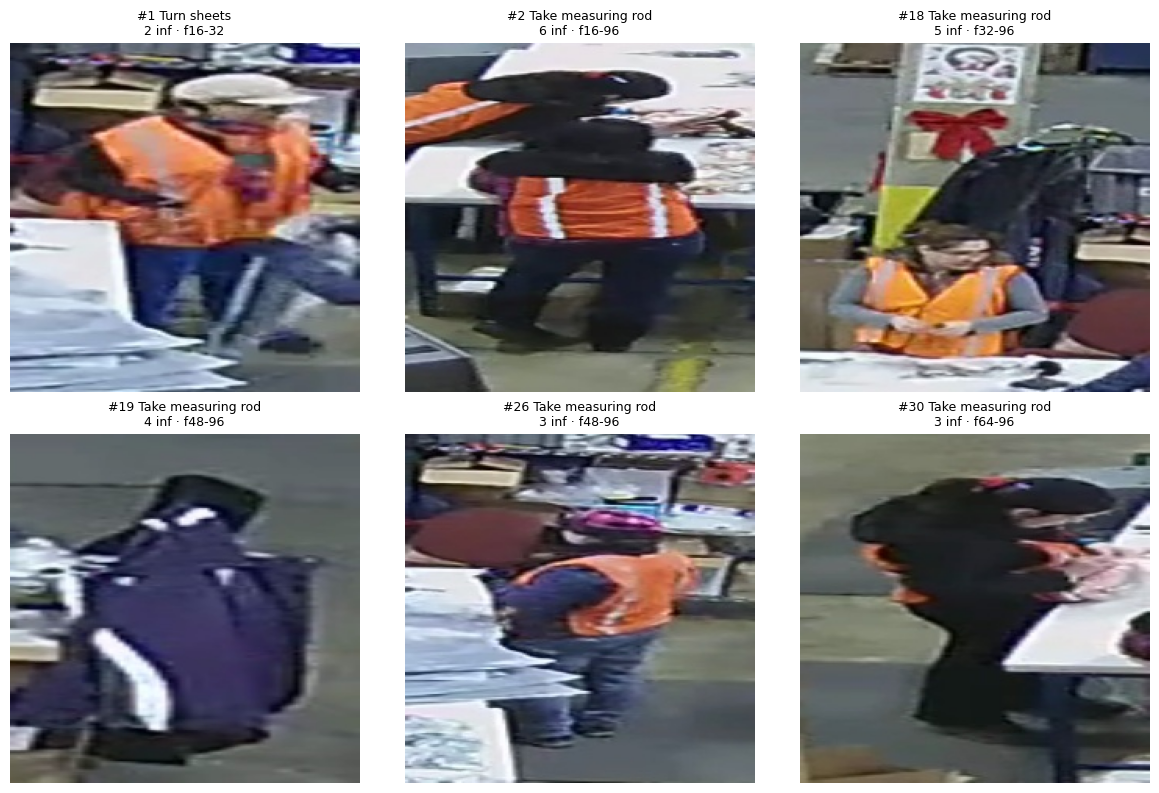

In [6]:
SHOW_TRACKS = tracks[:6]   # first N tracks
ncols = 3
nrows = (len(SHOW_TRACKS) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

for ax, tr in zip(axes, SHOW_TRACKS):
    path = tr.get('sample_crop') or tr.get('sample_frame')
    ax.set_title(
        f"#{tr['track_id']} {tr['dominant_action'][:18]}\n"
        f"{tr['n_inferences']} inf · f{tr['frame_first']}-{tr['frame_last']}",
        fontsize=9,
    )
    ax.axis('off')
    if path and Path(path).is_file():
        ax.imshow(plt.imread(path))
for ax in axes[len(SHOW_TRACKS):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

## 6 — Tag tracks: person or false detection?

Saved to `outputs/human_labels/track_labels.csv`. Use this to exclude forklift reflections, posters, etc. before retraining.

If Re-ID ran during eval, each track shows a **`global_person_id`**. Enter a **display name** when tagging — it is saved to `outputs/person_registry/registry.db`.

In [7]:
launch_track_tagger(SESSION_DIR, reviewer='supervisor')

In [8]:
load_track_labels_df().tail(10)

,label_id,session_id,track_id,video,person_verdict,action_notes,reviewer,reviewed_at,n_events,dominant_action,dominant_confidence
0,tl-bd22b07fd2,har-93944f1297de,1,Industrial-One.mp4,yes,NaN,supervisor,2026-06-12T21:01:02.326581+00:00,2,Turn sheets,0.6714
1,tl-02dff36b01,har-93944f1297de,2,Industrial-One.mp4,yes,NaN,supervisor,2026-06-12T21:01:03.308295+00:00,6,Take measuring rod,0.9871
2,tl-7e28e5ed2a,har-93944f1297de,18,Industrial-One.mp4,yes,NaN,supervisor,2026-06-12T21:01:07.828976+00:00,5,Take measuring rod,0.6490
3,tl-05d3d9a6a5,har-93944f1297de,19,Industrial-One.mp4,no,NaN,supervisor,2026-06-12T21:01:10.699332+00:00,4,Take measuring rod,0.9973
4,tl-ce3b4fb29d,har-93944f1297de,26,Industrial-One.mp4,yes,NaN,supervisor,2026-06-12T21:01:13.012980+00:00,3,Take measuring rod,0.9782
5,tl-18278930df,har-93944f1297de,30,Industrial-One.mp4,yes,NaN,supervisor,2026-06-12T21:01:15.182532+00:00,3,Take measuring rod,0.9773
6,tl-26dbaf4819,har-93944f1297de,30,Industrial-One.mp4,yes,NaN,supervisor,2026-06-12T21:01:16.477758+00:00,3,Take measuring rod,0.9773


## 6b — Person registry (cross-session history)

Stable person IDs live in `outputs/person_registry/registry.db`. Same worker re-detected in another video maps to the same ID when appearance embeddings match.

Browse all known persons, rename them, and inspect timelines across sessions.

In [9]:
print(f"Registry DB: {REGISTRY_DB}")
persons_df = persons_dataframe(limit=50)
if persons_df.empty:
    print("No persons yet — re-run 05 eval (person registry is on by default).")
else:
    display(persons_df[["global_person_id", "display_name", "n_appearances", "first_seen_at", "last_seen_at"]])

launch_person_registry_viewer(limit=50)

Registry DB: /Users/cpanoh/Documents/cpano-98-local/GitHub/AI-Co-Pilot-for-the-Production-Floor-See-Guide-Improve/har-research/outputs/person_registry/registry.db
No persons yet — re-run 05 eval (person registry is on by default).
No persons in registry yet — run 05 eval with logging (DB: /Users/cpanoh/Documents/cpano-98-local/GitHub/AI-Co-Pilot-for-the-Production-Floor-See-Guide-Improve/har-research/outputs/person_registry/registry.db)


## 7 — Tag individual actions (crop-level)

Open **07_Human_Label_Review.ipynb** for per-crop action verdicts (correct / wrong class).

Or run here:

In [12]:
# from lib.hitl_ui import launch_hitl_carousel
# launch_hitl_carousel(limit=100, reviewer='supervisor')

## 8 — Re-train with human labels

Verified crops + embeddings are merged in step **02** when `include_human_labels=True`, then **03** retrains the head.

In [13]:
from lib.human_labels import trainable_human_rows

rows = trainable_human_rows()
print(f'{len(rows)} human-verified samples ready for retraining')
if rows:
    pd.DataFrame(rows)[['predicted_label', 'correct_label', 'person_verdict', 'usable_for_training']].head()

0 human-verified samples ready for retraining
